In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def compute_hodge_laplacian_L1(edge_index, num_nodes):
    """
    Calcula o Hodge Laplacian L1 = B1^T @ B1
    
    Explicação:
    - B1 é a matriz de incidência [num_nodes, num_edges]
    - L1 conecta arestas que compartilham nós
    
    Args:
        edge_index: [2, num_edges] - [source_nodes, target_nodes]
        num_nodes: int - número de nós no grafo
    
    Returns:
        L1: [num_edges, num_edges] - Hodge Laplacian
        B1: [num_nodes, num_edges] - Matriz de incidência
    """
    num_edges = edge_index.shape[1]
    
    # Construir B1: matriz de incidência
    # B1[node, edge] = +1 se aresta SAI do node
    # B1[node, edge] = -1 se aresta CHEGA no node
    B1 = torch.zeros(num_nodes, num_edges, device=edge_index.device)
    
    for edge_idx in range(num_edges):
        source = edge_index[0, edge_idx]
        target = edge_index[1, edge_idx]
        
        B1[source, edge_idx] = 1   # Aresta sai
        B1[target, edge_idx] = -1  # Aresta chega
    
    # L1 = B1^T @ B1
    # Isso captura as relações entre arestas que compartilham nós
    L1 = B1.T @ B1
    
    return L1, B1


def normalize_hodge_laplacian(L1):
    """
    Normaliza o Hodge Laplacian (similar à normalização simétrica em GCN)
    
    L1_norm = D^(-1/2) @ L1 @ D^(-1/2)
    onde D é a matriz diagonal com graus
    
    Isso ajuda na estabilidade numérica durante o treinamento.
    """
    # Grau de cada "nó" (que é uma aresta no espaço L1)
    # degree[i] = número de arestas conectadas à aresta i
    degree = torch.abs(L1).sum(dim=1)  # [num_edges]
    
    # Evitar divisão por zero
    degree = torch.clamp(degree, min=1e-6)
    
    # D^(-1/2)
    deg_inv_sqrt = torch.pow(degree, -0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.
    
    # D^(-1/2) @ L1 @ D^(-1/2)
    L1_norm = deg_inv_sqrt.unsqueeze(1) * L1 * deg_inv_sqrt.unsqueeze(0)
    
    return L1_norm

In [14]:
class HodgeConvLayer(nn.Module):
    """
    Camada de convolução sobre arestas usando Hodge Laplacian.
    
    Funcionamento:
    1. Agrega features de arestas vizinhas usando L1
    2. Aplica transformação linear
    3. Aplica ativação e normalização
    
    É como uma GCNConv, mas opera em arestas!
    """
    def __init__(self, in_features, out_features, 
                 use_bias=True, activation='relu', 
                 batch_norm=True, dropout=0.0):
        super().__init__()
        
        self.in_features = in_features
        self.out_features = out_features
        
        # Transformação linear (como em GCN)
        self.linear = nn.Linear(in_features, out_features, bias=use_bias)
        
        # Batch normalization (opcional)
        self.batch_norm = nn.BatchNorm1d(out_features) if batch_norm else None
        
        # Função de ativação
        if activation == 'relu':
            self.activation = F.relu
        elif activation == 'elu':
            self.activation = F.elu
        elif activation == 'leaky_relu':
            self.activation = F.leaky_relu
        else:
            self.activation = lambda x: x
        
        self.dropout = dropout
        
    def forward(self, edge_features, L1):
        """
        Args:
            edge_features: [num_edges, in_features]
            L1: [num_edges, num_edges] - Hodge Laplacian (já normalizado)
        
        Returns:
            out: [num_edges, out_features]
        """
        # 1. Agregação: cada aresta agrega info de arestas vizinhas
        aggregated = L1 @ edge_features  # [num_edges, in_features]
        
        # 2. Transformação linear
        out = self.linear(aggregated)  # [num_edges, out_features]
        
        # 3. Batch normalization (se configurado)
        if self.batch_norm is not None:
            out = self.batch_norm(out)
        
        # 4. Ativação
        out = self.activation(out)
        
        # 5. Dropout (apenas durante treinamento)
        out = F.dropout(out, p=self.dropout, training=self.training)
        
        return out

In [15]:
from torch_geometric.nn import global_mean_pool, global_max_pool, global_add_pool

class HodgeGNN(nn.Module):
    def __init__(self, 
                 num_classes=2,
                 hidden_dims=[64, 64, 32],          # Convoluções
                 mlp_hidden_dims=[128, 64],         # ← NOVO! MLP customizável
                 pooling='mean',
                 dropout=0.5,
                 batch_norm=True,
                 activation='relu',
                 normalize_L1=True):
        super().__init__()
        
        self.pooling = pooling
        self.normalize_L1 = normalize_L1
        
        # Convoluções (igual antes)
        self.convs = nn.ModuleList()
        self.convs.append(
            HodgeConvLayer(1, hidden_dims[0], 
                          batch_norm=batch_norm,
                          activation=activation,
                          dropout=dropout)
        )
        for i in range(len(hidden_dims) - 1):
            self.convs.append(
                HodgeConvLayer(hidden_dims[i], hidden_dims[i+1],
                              batch_norm=batch_norm,
                              activation=activation,
                              dropout=dropout)
            )
        
        # MLP Classificador - CUSTOMIZÁVEL! ✨
        mlp_layers = []
        
        # Input do MLP: saída das convoluções após pooling
        input_dim = hidden_dims[-1]
        
        # Camadas ocultas do MLP
        for mlp_dim in mlp_hidden_dims:
            mlp_layers.append(nn.Linear(input_dim, mlp_dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(dropout))
            input_dim = mlp_dim
        
        # Camada final: última hidden_dim → num_classes
        mlp_layers.append(nn.Linear(input_dim, num_classes))
        
        self.classifier = nn.Sequential(*mlp_layers)
                
    def forward(self, x, edge_index, batch):
        """
        Args:
            x: [num_nodes, num_node_features] - NÃO USADO! 
               (HodgeGNN opera apenas em arestas)
            edge_index: [2, num_edges] - conectividade
            batch: [num_nodes] - indica qual nó pertence a qual grafo
        
        Returns:
            logits: [batch_size, num_classes]
        """
        device = edge_index.device
        num_nodes = x.shape[0]
        num_edges = edge_index.shape[1]
        
        # Extrair edge_batch: qual aresta pertence a qual grafo
        # edge_batch[i] = índice do grafo ao qual a aresta i pertence
        edge_batch = batch[edge_index[0]]  # [num_edges]
        
        # ===== PASSO 1: Calcular Hodge Laplacian L1 =====
        L1, B1 = compute_hodge_laplacian_L1(edge_index, num_nodes)
        
        # Normalizar L1 (opcional, mas geralmente melhora)
        if self.normalize_L1:
            L1 = normalize_hodge_laplacian(L1)
        
        # ===== PASSO 2: Edge Features Iniciais =====
        # No paper, eles usam os pesos das arestas
        # Como MUTAG tem edge_attr, podemos usar
        # Por simplicidade, vamos usar "grau" das arestas como feature inicial
        edge_features = torch.ones(num_edges, 1, device=device)  # [num_edges, 1]
        
        # ===== PASSO 3: Convoluções em Arestas =====
        h = edge_features
        for conv in self.convs:
            h = conv(h, L1)
        # h agora é [num_edges, hidden_dims[-1]]
        
        # ===== PASSO 4: Pooling (agregar arestas → grafo) =====
        if self.pooling == 'mean':
            h_graph = global_mean_pool(h, edge_batch)
        elif self.pooling == 'max':
            h_graph = global_max_pool(h, edge_batch)
        elif self.pooling == 'sum':
            h_graph = global_add_pool(h, edge_batch)
        # h_graph agora é [batch_size, hidden_dims[-1]]
        
        # ===== PASSO 5: Classificação =====
        logits = self.classifier(h_graph)
        
        return logits

In [16]:
class GraphClassificationTrainer:
    def __init__(self, model, fold_loaders, config, device='cpu'):
        self.model = model.to(device)
        self.fold_loaders = fold_loaders
        self.config = config
        self.device = device
        
        # Configurando otimizador
        if config['optimizer'] == 'adam':
            self.optimizer = torch.optim.Adam(
                model.parameters(),
                lr=config['lr'],
                weight_decay=config['weight_decay']
            )
        
        # Scheduler de learning rate
        if config.get('scheduler') == 'step':
            self.scheduler = torch.optim.lr_scheduler.StepLR(
                self.optimizer,
                step_size=config['step_size'],
                gamma=config['gamma']
            )
        elif config.get('scheduler') == 'cosine':
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer,
                T_max=config['epochs']
            )
        else:
            self.scheduler = None
        
        self.criterion = torch.nn.CrossEntropyLoss()
        
        # Para early stopping
        self.best_val_acc = 0
        self.patience_counter = 0
        self.best_model_state = None
    
    def train_epoch(self, train_loader):
        """
        Treina por uma época completa, iterando sobre todos os batches.
        """
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch in train_loader:
            # Move o batch para o device apropriado (CPU ou GPU)
            batch = batch.to(self.device)
            
            self.optimizer.zero_grad()
            
            # Forward pass
            # Note que agora passamos batch.batch para indicar os limites dos grafos
            out = self.model(batch.x, batch.edge_index, batch.batch)
            
            # Calcula a perda
            loss = self.criterion(out, batch.y)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping se configurado
            if self.config.get('clip_grad'):
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    self.config['clip_grad']
                )
            
            self.optimizer.step()
            
            # Acumula estatísticas
            total_loss += loss.item() * batch.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
            total += batch.num_graphs
        
        avg_loss = total_loss / total
        accuracy = correct / total
        
        return avg_loss, accuracy
    
    @torch.no_grad()
    def evaluate(self, loader):
        """
        Avalia o modelo em um DataLoader específico.
        """
        self.model.eval()
        correct = 0
        total = 0
        
        for batch in loader:
            batch = batch.to(self.device)
            out = self.model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
            total += batch.num_graphs
        
        return correct / total
    
    def train_fold(self, fold_idx):
        """
        Treina o modelo em um fold específico da validação cruzada.
        """
        print(f'\n=== Treinando Fold {fold_idx + 1} ===')
        
        # Reseta o modelo para cada fold
        self.model.apply(self._weight_reset)
        
        # Reseta otimizador e scheduler
        self.__init__(self.model, self.fold_loaders, self.config, self.device)
        
        loaders = self.fold_loaders[fold_idx]
        train_loader = loaders['train']
        val_loader = loaders['val']
        test_loader = loaders['test']
        
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_acc': [],
            'test_acc': []
        }
        
        self.best_val_acc = 0
        self.patience_counter = 0
        
        for epoch in range(1, self.config['epochs'] + 1):
            # Treina por uma época
            train_loss, train_acc = self.train_epoch(train_loader)
            
            # Avalia em validação e teste
            val_acc = self.evaluate(val_loader)
            test_acc = self.evaluate(test_loader)
            
            # Guarda histórico
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            history['test_acc'].append(test_acc)
            
            # Atualiza learning rate
            if self.scheduler is not None:
                self.scheduler.step()
            
            # Early stopping
            if self.config.get('early_stopping'):
                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    self.best_model_state = self.model.state_dict().copy()
                    self.patience_counter = 0
                else:
                    self.patience_counter += 1
                
                if self.patience_counter >= self.config['patience']:
                    print(f'Early stopping na época {epoch}')
                    self.model.load_state_dict(self.best_model_state)
                    break
            
            # Log periódico
            if epoch % self.config['log_interval'] == 0:
                print(f'Época {epoch:03d}: Loss={train_loss:.4f}, '
                      f'Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')
        
        # Avaliação final no melhor modelo
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
        
        final_val_acc = self.evaluate(val_loader)
        final_test_acc = self.evaluate(test_loader)
        
        print(f'Melhor Val Acc: {final_val_acc:.4f}')
        print(f'Test Acc final: {final_test_acc:.4f}')
        
        return history, final_val_acc, final_test_acc
    
    def train_all_folds(self):
        """
        Executa validação cruzada completa em todos os folds.
        """
        val_accs = []
        test_accs = []
        all_histories = []
        
        for fold_idx in range(len(self.fold_loaders)):
            history, val_acc, test_acc = self.train_fold(fold_idx)
            val_accs.append(val_acc)
            test_accs.append(test_acc)
            all_histories.append(history)
        
        # Calcula estatísticas agregadas
        mean_val_acc = np.mean(val_accs)
        std_val_acc = np.std(val_accs)
        mean_test_acc = np.mean(test_accs)
        std_test_acc = np.std(test_accs)
        
        print('\n' + '='*50)
        print('RESULTADOS DA VALIDAÇÃO CRUZADA')
        print('='*50)
        print(f'Validação: {mean_val_acc:.4f} ± {std_val_acc:.4f}')
        print(f'Teste: {mean_test_acc:.4f} ± {std_test_acc:.4f}')
        print('='*50)
        
        return {
            'val_accs': val_accs,
            'test_accs': test_accs,
            'mean_val_acc': mean_val_acc,
            'std_val_acc': std_val_acc,
            'mean_test_acc': mean_test_acc,
            'std_test_acc': std_test_acc,
            'histories': all_histories
        }
    
    @staticmethod
    def _weight_reset(m):
        """
        Reseta os pesos de uma camada para reinicialização.
        """
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()

In [17]:
# ===== CÉLULA 1: Imports =====
from utils.utils import set_seed
import torch
set_seed(12)

# ===== CÉLULA 2: Carregar Dataset (você já tem isso) =====
from torch_geometric.datasets import TUDataset
dataset = TUDataset(root="/tmp/MUTAG", name="MUTAG")

# ===== CÉLULA 3: Criar splits (você já tem isso) =====
from sklearn.model_selection import StratifiedKFold
from torch_geometric.loader import DataLoader
import numpy as np
def create_data_splits(dataset, n_splits=10, batch_size=32, random_seed=42):
    """
    Cria splits para validação cruzada k-fold estratificada.
    
    A estratificação garante que cada fold tenha aproximadamente a mesma
    proporção de classes que o dataset completo. Isso é importante porque
    temos um desbalanceamento de classes no MUTAG.
    """
    # Extraindo os labels para estratificação
    y = np.array([data.y.item() for data in dataset])
    
    # Criando o objeto de validação cruzada
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    
    # Lista para armazenar os loaders de cada fold
    fold_loaders = []
    
    for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
        # Dividimos train_val_idx em treino e validação (80/20)
        # Usamos estratificação novamente aqui
        inner_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
        train_idx, val_idx = next(inner_skf.split(
            np.zeros(len(train_val_idx)), 
            y[train_val_idx]
        ))
        
        # Convertendo índices relativos para absolutos
        train_idx = train_val_idx[train_idx]
        val_idx = train_val_idx[val_idx]
        
        # Criando subsets
        train_dataset = dataset[train_idx.tolist()]
        val_dataset = dataset[val_idx.tolist()]
        test_dataset = dataset[test_idx.tolist()]
        
        # Criando DataLoaders
        # O DataLoader do PyG automaticamente faz o batching de múltiplos grafos
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        fold_loaders.append({
            'train': train_loader,
            'val': val_loader,
            'test': test_loader,
            'train_size': len(train_dataset),
            'val_size': len(val_dataset),
            'test_size': len(test_dataset)
        })
        
        if fold_idx == 0:
            print(f'Fold {fold_idx + 1}:')
            print(f'  Treino: {len(train_dataset)} grafos')
            print(f'  Validação: {len(val_dataset)} grafos')
            print(f'  Teste: {len(test_dataset)} grafos')
    
    return fold_loaders

# Criando os splits
fold_loaders = create_data_splits(dataset, n_splits=4, batch_size=32)
# ===== CÉLULA 4: Cole TODAS as funções que te passei acima =====
# compute_hodge_laplacian_L1
# normalize_hodge_laplacian
# HodgeConvLayer
# HodgeGNN

# ===== CÉLULA 5: Treinar HodgeGNN =====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando device: {device}')

# Criar modelo
model = HodgeGNN(
    num_classes=dataset.num_classes,
    hidden_dims=[32, 32, 32, 32],
    mlp_hidden_dims= [128],  # 3 camadas
    pooling='sum',  
    dropout=0.0,
    batch_norm=True,
    activation='leaky_relu',
    normalize_L1=True
)

# Configuração de treinamento
config = {
    'optimizer': 'adam',
    'lr': 0.1,
    'weight_decay': 0,
    # 'scheduler': 'step',
    # 'step_size': 50,
    # 'gamma': 0.5,
    'epochs': 100,
    # 'clip_grad': 1.0,
    # 'early_stopping': True,
    # 'patience': 50,
    'log_interval': 10
}

# Treinar com seu trainer existente!
trainer = GraphClassificationTrainer(model, fold_loaders, config, device=device)
results = trainer.train_all_folds()

print("\n🎉 Resultados HodgeGNN:")
print(f"Validação: {results['mean_val_acc']:.4f} ± {results['std_val_acc']:.4f}")
print(f"Teste: {results['mean_test_acc']:.4f} ± {results['std_test_acc']:.4f}")

Seed fixada em 12
Fold 1:
  Treino: 112 grafos
  Validação: 29 grafos
  Teste: 47 grafos
Usando device: cpu

=== Treinando Fold 1 ===
Época 010: Loss=0.9167, Train=0.8125, Val=0.7931, Test=0.8511
Época 020: Loss=2.2299, Train=0.6429, Val=0.7586, Test=0.7660
Época 030: Loss=0.6020, Train=0.7946, Val=0.6552, Test=0.7234
Época 040: Loss=0.4473, Train=0.8393, Val=0.7931, Test=0.7447
Época 050: Loss=0.3585, Train=0.8036, Val=0.6897, Test=0.8085
Época 060: Loss=0.3405, Train=0.8750, Val=0.7241, Test=0.8723
Época 070: Loss=0.3361, Train=0.8750, Val=0.7241, Test=0.7872
Época 080: Loss=0.3501, Train=0.8750, Val=0.6552, Test=0.7234
Época 090: Loss=0.3572, Train=0.9018, Val=0.7241, Test=0.8085
Época 100: Loss=0.3940, Train=0.8571, Val=0.7241, Test=0.8511
Melhor Val Acc: 0.7241
Test Acc final: 0.8511

=== Treinando Fold 2 ===
Época 010: Loss=0.7239, Train=0.6518, Val=0.3448, Test=0.3404
Época 020: Loss=0.4941, Train=0.7679, Val=0.3448, Test=0.3404
Época 030: Loss=0.4488, Train=0.8214, Val=0.8966, 

Coletando predições de todos os folds no conjunto de teste...
Fold 1: 47 amostras coletadas
Fold 2: 47 amostras coletadas
Fold 3: 47 amostras coletadas
Fold 4: 47 amostras coletadas

Total de amostras: 188


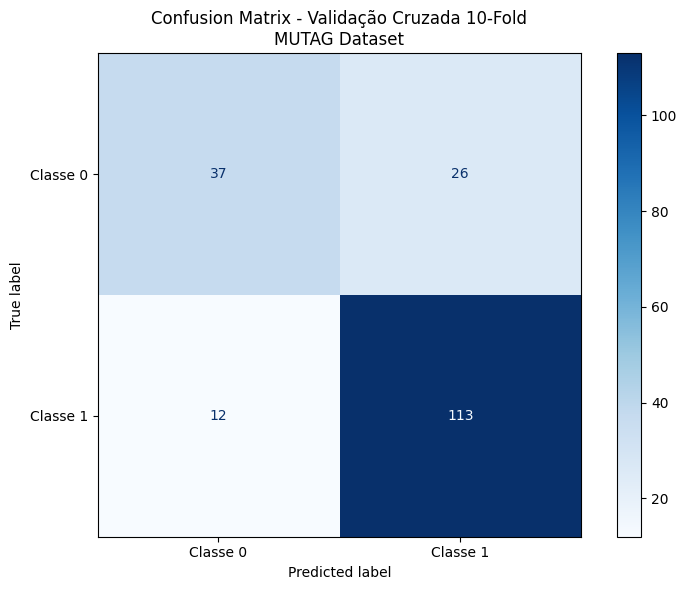


MATRIZ DE CONFUSÃO
True Negatives (TN): 37
False Positives (FP): 26
False Negatives (FN): 12
True Positives (TP): 113

Métricas:
Accuracy: 0.7979
Precision: 0.8129
Recall: 0.9040
F1-Score: 0.8561


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_predictions_for_fold(model, loader, device):
    """
    Coleta todas as predições e labels verdadeiros para um loader.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    
    return all_preds, all_labels

# Treinar novamente o último fold para ter o modelo carregado
# Ou podemos coletar predições de todos os folds
all_preds = []
all_labels = []

print("Coletando predições de todos os folds no conjunto de teste...")

for fold_idx in range(len(fold_loaders)):
    # Reseta e treina o modelo para este fold
    trainer.model.apply(trainer._weight_reset)
    trainer.__init__(trainer.model, fold_loaders, config, device=device)
    
    # Treina o fold silenciosamente
    loaders = fold_loaders[fold_idx]
    train_loader = loaders['train']
    val_loader = loaders['val']
    test_loader = loaders['test']
    
    best_val_acc = 0
    patience_counter = 0
    best_model_state = None
    
    # Treinamento simplificado sem prints
    for epoch in range(1, config['epochs'] + 1):
        trainer.model.train()
        for batch in train_loader:
            batch = batch.to(device)
            trainer.optimizer.zero_grad()
            out = trainer.model(batch.x, batch.edge_index, batch.batch)
            loss = trainer.criterion(out, batch.y)
            loss.backward()
            if config.get('clip_grad'):
                torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), config['clip_grad'])
            trainer.optimizer.step()
        
        if trainer.scheduler is not None:
            trainer.scheduler.step()
        
        # Validação para early stopping
        val_acc = trainer.evaluate(val_loader)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = trainer.model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # if patience_counter >= config['patience']:
        #     break
    
    # Carrega o melhor modelo
    if best_model_state is not None:
        trainer.model.load_state_dict(best_model_state)
    
    # Coleta predições do conjunto de teste
    preds, labels = get_predictions_for_fold(trainer.model, test_loader, device)
    all_preds.extend(preds)
    all_labels.extend(labels)
    
    print(f"Fold {fold_idx + 1}: {len(preds)} amostras coletadas")

print(f"\nTotal de amostras: {len(all_preds)}")

# Criar a matriz de confusão
cm = confusion_matrix(all_labels, all_preds)

# Plotar a matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Validação Cruzada 10-Fold\nMUTAG Dataset')
plt.tight_layout()
plt.show()

# Imprimir estatísticas
print("\n" + "="*50)
print("MATRIZ DE CONFUSÃO")
print("="*50)
print(f"True Negatives (TN): {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP): {cm[1,1]}")
print("\nMétricas:")
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("="*50)